# EDA + Experimentos A/B Semana 5 — Pipeline USD/PEN

Notebook consolidado para el entregable de Semana 5: EDA, baseline, experimentos A/B, validación temporal reforzada, PR Curve, calibración de umbral, decisión experimental y logs reproducibles.

**Criterio metodológico:** las features predictivas usan información pasada (`shift`) para evitar leakage.

# 0. Configuración inicial

En esta sección se configuran los parámetros generales del notebook, las rutas del proyecto, la semilla de reproducibilidad y las librerías necesarias.

Se define una semilla fija (`RANDOM_SEED = 42`) para asegurar que los experimentos sean reproducibles. También se registran las versiones principales del entorno de ejecución para facilitar trazabilidad.

In [63]:
from pathlib import Path
from datetime import datetime
import json
import platform
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score
)
from sklearn.model_selection import TimeSeriesSplit

warnings.filterwarnings("ignore")

# =========================
# PARÁMETROS EDITABLES
# =========================
START_DATE = "2025-07-01"
END_DATE = "2026-05-08"
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

PROJECT_ROOT = Path(r"C:\Users\Thomy\Cursos\Proyecto_1\Proyecto_Tesis_1\news-sentiment-pipeline")

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
MARKET_DIR = DATA_DIR / "market"
FIGS_DIR = PROJECT_ROOT / "figs"
LOGS_DIR = PROJECT_ROOT / "logs"

FIGS_DIR.mkdir(exist_ok=True, parents=True)
LOGS_DIR.mkdir(exist_ok=True, parents=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("MARKET_DIR:", MARKET_DIR)
print("FIGS_DIR:", FIGS_DIR)
print("LOGS_DIR:", LOGS_DIR)
print("Python:", platform.python_version())
print("Platform:", platform.platform())
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Seed:", RANDOM_SEED)

PROJECT_ROOT: C:\Users\Thomy\Cursos\Proyecto_1\Proyecto_Tesis_1\news-sentiment-pipeline
PROCESSED_DIR: C:\Users\Thomy\Cursos\Proyecto_1\Proyecto_Tesis_1\news-sentiment-pipeline\data\processed
MARKET_DIR: C:\Users\Thomy\Cursos\Proyecto_1\Proyecto_Tesis_1\news-sentiment-pipeline\data\market
FIGS_DIR: C:\Users\Thomy\Cursos\Proyecto_1\Proyecto_Tesis_1\news-sentiment-pipeline\figs
LOGS_DIR: C:\Users\Thomy\Cursos\Proyecto_1\Proyecto_Tesis_1\news-sentiment-pipeline\logs
Python: 3.12.7
Platform: Windows-11-10.0.26200-SP0
Pandas: 3.0.2
NumPy: 2.1.2
Scikit-learn: 1.8.0
Seed: 42


# 1. Carga de datos

En esta sección se cargan los archivos generados por el pipeline:

- `news_clean.csv`: noticias limpias
- `news_scores.csv`: scores de sentimiento por noticia
- `daily_sentiment.csv`: sentimiento agregado diario
- `compare_sentiment_vs_fx.csv`: comparación contra USD/PEN
- `daily_evaluation_table.csv`: evaluación diaria
- `usdpen_yahoo.csv`: datos reales del tipo de cambio USD/PEN

Esta carga permite validar que el pipeline generó correctamente los insumos necesarios para el análisis exploratorio y los experimentos A/B.

In [64]:
files = {
    "news_clean": PROCESSED_DIR / "news_clean.csv",
    "news_scores": PROCESSED_DIR / "news_scores.csv",
    "daily_sentiment": PROCESSED_DIR / "daily_sentiment.csv",
    "compare_fx": PROCESSED_DIR / "compare_sentiment_vs_fx.csv",
    "daily_eval": PROCESSED_DIR / "daily_evaluation_table.csv",
    "usdpen": MARKET_DIR / "usdpen_yahoo.csv",
}

datasets = {}

for name, path in files.items():
    if path.exists():
        df = pd.read_csv(path)
        datasets[name] = df
        print(f"✓ Cargado: {path.relative_to(PROJECT_ROOT)} | shape={df.shape}")
    else:
        print(f"⚠ No encontrado: {path.relative_to(PROJECT_ROOT)}")

news_clean = datasets.get("news_clean")
news_scores = datasets.get("news_scores")
daily_sentiment = datasets.get("daily_sentiment")
compare_fx = datasets.get("compare_fx")
daily_eval = datasets.get("daily_eval")
usdpen = datasets.get("usdpen")

print("\nColumnas disponibles:")
for name, df in datasets.items():
    print(f"{name}: {df.columns.tolist()}")

✓ Cargado: data\processed\news_clean.csv | shape=(2906, 10)
✓ Cargado: data\processed\news_scores.csv | shape=(2849, 7)
✓ Cargado: data\processed\daily_sentiment.csv | shape=(122, 8)
✓ Cargado: data\processed\compare_sentiment_vs_fx.csv | shape=(90, 13)
✓ Cargado: data\processed\daily_evaluation_table.csv | shape=(90, 6)
✓ Cargado: data\market\usdpen_yahoo.csv | shape=(223, 7)

Columnas disponibles:
news_clean: ['news_id', 'source', 'url', 'published_at', 'fetched_at', 'title_raw', 'body_raw', 'content_hash', 'lang_hint', 'reliability_weight']
news_scores: ['news_id', 'sentiment_model', 'sentiment_label', 'p_pos', 'p_neu', 'p_neg', 'language']
daily_sentiment: ['date', 'asset', 'n_news_total', 'sent_index_mean', 'sent_index_strength', 'share_pos', 'share_neg', 'share_neu']
compare_fx: ['date', 'asset', 'n_news_total', 'sent_index_mean', 'sent_index_strength', 'share_pos', 'share_neg', 'share_neu', 'open', 'close', 'signal', 'real_dir', 'hit']
daily_eval: ['Fecha', 'Señal Sentimiento', 

# 2. Versión de datos y control de calidad inicial

En esta etapa se realiza un control inicial de calidad de datos.

Se revisan:

- cantidad de filas y columnas
- valores nulos
- duplicados por `news_id`
- duplicados por `content_hash`
- estructura de columnas por archivo

Además, se genera un snapshot en `logs/data_version_week5.json` para dejar evidencia de la versión de datos utilizada en los experimentos.

In [65]:
snapshot = {
    "generated_at": datetime.now().isoformat(),
    "start_date": START_DATE,
    "end_date": END_DATE,
    "random_seed": RANDOM_SEED,
    "files": {}
}

for name, df in datasets.items():
    print(f"\n=== {name} ===")
    print("Shape:", df.shape)
    
    nulls = df.isnull().sum().sort_values(ascending=False)
    print("\nNulos principales:")
    print(nulls[nulls > 0].head(10))
    
    if "news_id" in df.columns:
        print("news_id únicos:", df["news_id"].nunique())
        print("duplicados news_id:", df.duplicated(subset=["news_id"]).sum())
    
    if "content_hash" in df.columns:
        print("duplicados content_hash:", df.duplicated(subset=["content_hash"]).sum())
    
    snapshot["files"][name] = {
        "rows": int(df.shape[0]),
        "columns": int(df.shape[1]),
        "column_names": df.columns.tolist()
    }

snapshot_path = LOGS_DIR / "data_version_week5.json"

with open(snapshot_path, "w", encoding="utf-8") as f:
    json.dump(snapshot, f, indent=2, ensure_ascii=False)

print(f"\n✓ Snapshot guardado en {snapshot_path.relative_to(PROJECT_ROOT)}")


=== news_clean ===
Shape: (2906, 10)

Nulos principales:
body_raw        57
published_at    12
title_raw        5
dtype: int64
news_id únicos: 2906
duplicados news_id: 0
duplicados content_hash: 0

=== news_scores ===
Shape: (2849, 7)

Nulos principales:
Series([], dtype: int64)
news_id únicos: 2849
duplicados news_id: 0

=== daily_sentiment ===
Shape: (122, 8)

Nulos principales:
Series([], dtype: int64)

=== compare_fx ===
Shape: (90, 13)

Nulos principales:
Series([], dtype: int64)

=== daily_eval ===
Shape: (90, 6)

Nulos principales:
Series([], dtype: int64)

=== usdpen ===
Shape: (223, 7)

Nulos principales:
date    1
dtype: int64

✓ Snapshot guardado en logs\data_version_week5.json


# 3. Preparación del dataset diario

En esta sección se prepara el dataset diario para modelamiento.

Se utiliza como base `compare_sentiment_vs_fx.csv`, que integra:

- indicadores diarios de sentimiento
- volumen de noticias
- proporciones positivas, negativas y neutrales
- apertura y cierre del USD/PEN
- dirección real del tipo de cambio

También se construye la variable objetivo:

- `target_up = 1`: el USD/PEN sube
- `target_up = 0`: el USD/PEN baja

Esta formulación convierte el problema en una tarea de clasificación binaria.

In [66]:
df_daily = compare_fx.copy()

df_daily["date"] = pd.to_datetime(df_daily["date"], errors="coerce")
df_daily = df_daily.dropna(subset=["date"])

df_daily = df_daily[
    (df_daily["date"] >= pd.to_datetime(START_DATE)) &
    (df_daily["date"] <= pd.to_datetime(END_DATE))
].copy()

df_daily = df_daily.sort_values("date").reset_index(drop=True)

# Asegurar columnas numéricas
numeric_cols = [
    "n_news_total",
    "sent_index_mean",
    "sent_index_strength",
    "share_pos",
    "share_neg",
    "share_neu",
    "open",
    "close"
]

for c in numeric_cols:
    if c in df_daily.columns:
        df_daily[c] = pd.to_numeric(df_daily[c], errors="coerce")

# Crear dirección real si no existe
if "real_dir" not in df_daily.columns:
    df_daily["real_dir"] = np.where(df_daily["close"] > df_daily["open"], "UP", "DOWN")

# Target binario
df_daily["target_up"] = (df_daily["real_dir"] == "UP").astype(int)

# Retorno intradía
df_daily["fx_diff"] = df_daily["close"] - df_daily["open"]
df_daily["fx_return"] = df_daily["fx_diff"] / df_daily["open"]

print("Fechas consideradas:")
print("Inicio:", df_daily["date"].min())
print("Fin:", df_daily["date"].max())
print("Filas:", len(df_daily))

display(df_daily.head())
display(df_daily.tail())

Fechas consideradas:
Inicio: 2025-07-03 00:00:00
Fin: 2026-05-08 00:00:00
Filas: 90


,date,asset,n_news_total,sent_index_mean,sent_index_strength,share_pos,share_neg,share_neu,open,close,signal,real_dir,hit,target_up,fx_diff,fx_return
0,2025-07-03,USD/PEN,28,0.115051,0.086935,0.035714,0.0,0.964286,3.484046,3.484046,UP,FLAT,0,0,0.0,0.0
1,2025-07-07,USD/PEN,27,0.167342,0.109434,0.037037,0.0,0.962963,3.477862,3.477862,UP,FLAT,0,0,0.0,0.0
2,2025-07-09,USD/PEN,28,0.106546,0.081561,0.035714,0.0,0.964286,3.542000,3.542000,UP,FLAT,0,0,0.0,0.0
3,2025-07-14,USD/PEN,29,0.152271,0.106098,0.068966,0.0,0.931034,3.476722,3.476722,UP,FLAT,0,0,0.0,0.0
4,2025-07-16,USD/PEN,28,0.189611,0.134425,0.142857,0.0,0.857143,3.560500,3.560500,UP,FLAT,0,0,0.0,0.0


,date,asset,n_news_total,sent_index_mean,sent_index_strength,share_pos,share_neg,share_neu,open,close,signal,real_dir,hit,target_up,fx_diff,fx_return
85,2026-05-04,USD/PEN,28,0.091888,0.070201,0.035714,0.000000,0.964286,3.439655,3.507,UP,UP,1,1,0.067345,0.019579
86,2026-05-05,USD/PEN,2,-0.414685,-0.368068,0.000000,0.500000,0.500000,3.504000,3.504,DOWN,FLAT,0,0,0.000000,0.000000
87,2026-05-06,USD/PEN,28,0.063189,0.046844,0.035714,0.035714,0.928571,3.430240,3.488,UP,UP,1,1,0.057760,0.016838
88,2026-05-07,USD/PEN,3,0.340710,0.284812,0.333333,0.000000,0.666667,3.396879,3.462,UP,UP,1,1,0.065121,0.019171
89,2026-05-08,USD/PEN,137,0.080065,0.045610,0.197080,0.138686,0.664234,3.406813,3.457,UP,UP,1,1,0.050187,0.014731


# 4. Estadísticas descriptivas y desbalance

En esta etapa se analizan las estadísticas descriptivas del dataset diario.

Se revisan variables como:

- número de noticias por día
- índice promedio de sentimiento
- fuerza del sentimiento
- proporción positiva
- proporción negativa
- proporción neutral
- variación del USD/PEN

También se evalúa la distribución del target (`UP` / `DOWN`) para identificar posible desbalance de clases.

Este punto es importante porque, si una clase domina demasiado, métricas como Accuracy pueden ser engañosas. Por ello, se complementa la evaluación con F1-score y PR-AUC.

In [67]:
eda_cols = [
    "n_news_total",
    "sent_index_mean",
    "sent_index_strength",
    "share_pos",
    "share_neg",
    "share_neu",
    "fx_diff",
    "fx_return"
]

eda_cols = [c for c in eda_cols if c in df_daily.columns]

print("Shape:", df_daily.shape)

display(df_daily[eda_cols].describe().T)

print("\nDistribución del target:")
print(df_daily["real_dir"].value_counts())

print("\nDistribución porcentual:")
print(df_daily["real_dir"].value_counts(normalize=True))

Shape: (90, 16)


,count,mean,std,min,25%,50%,75%,max
n_news_total,90.0,25.133333,19.563897,1.000000,26.000000,28.000000,29.000000,137.000000
sent_index_mean,90.0,0.090998,0.136190,-0.782129,0.070615,0.105265,0.136590,0.556626
sent_index_strength,90.0,0.065177,0.101367,-0.621655,0.056306,0.080624,0.098559,0.318593
share_pos,90.0,0.052365,0.113158,0.000000,0.000000,0.034483,0.068966,1.000000
share_neg,90.0,0.030876,0.123658,0.000000,0.000000,0.000000,0.000000,1.000000
share_neu,90.0,0.916759,0.165459,0.000000,0.928571,0.964286,1.000000,1.000000
fx_diff,90.0,0.022115,0.035838,-0.068395,0.000000,0.000000,0.062734,0.126911
fx_return,90.0,0.006646,0.010739,-0.019819,0.000000,0.000000,0.018925,0.038317



Distribución del target:
real_dir
UP      41
FLAT    38
DOWN    11
Name: count, dtype: int64

Distribución porcentual:
real_dir
UP      0.455556
FLAT    0.422222
DOWN    0.122222
Name: proportion, dtype: float64


# 5. Visualizaciones EDA

En esta sección se generan gráficos exploratorios para entender el comportamiento temporal del dataset.

Se visualiza:

- cantidad de noticias por día
- proporción diaria de sentimiento positivo, negativo y neutral
- distribución del índice diario de sentimiento

Estos gráficos permiten identificar patrones temporales, picos de noticias, predominancia de sentimiento neutral y posibles eventos extremos.

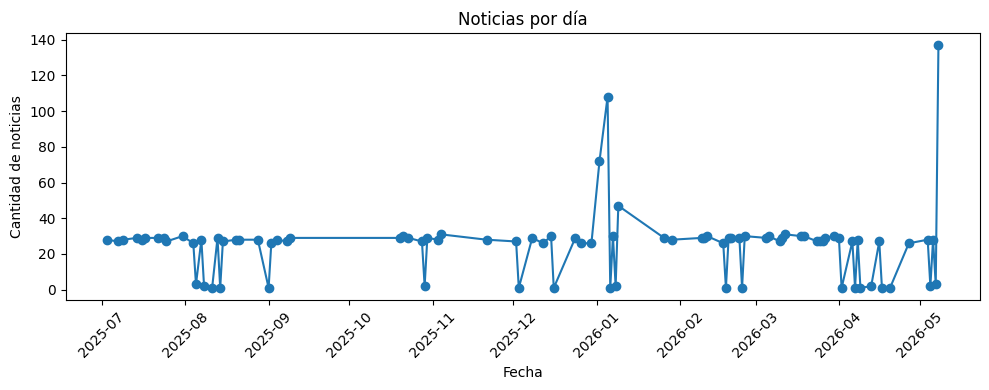

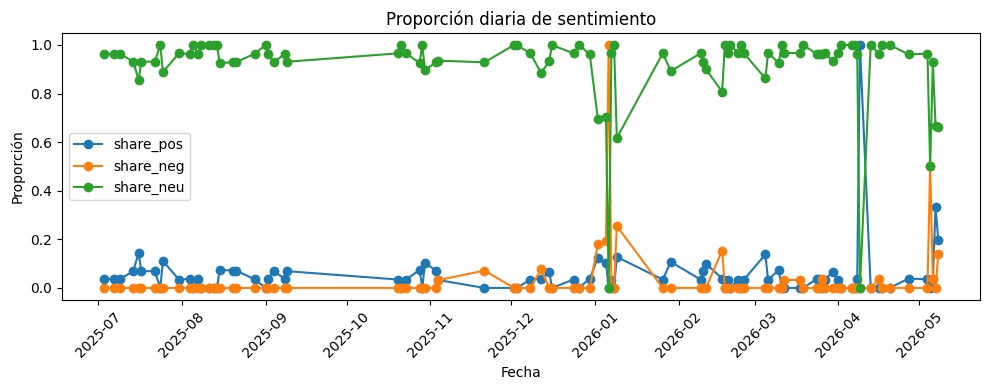

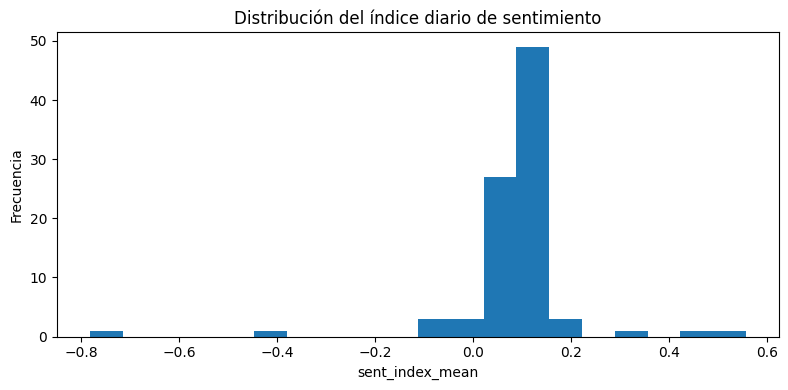

In [68]:
plt.figure(figsize=(10, 4))
plt.plot(df_daily["date"], df_daily["n_news_total"], marker="o")
plt.title("Noticias por día")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de noticias")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGS_DIR / "week5_news_per_day.png", dpi=150)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(df_daily["date"], df_daily["share_pos"], marker="o", label="share_pos")
plt.plot(df_daily["date"], df_daily["share_neg"], marker="o", label="share_neg")
plt.plot(df_daily["date"], df_daily["share_neu"], marker="o", label="share_neu")
plt.title("Proporción diaria de sentimiento")
plt.xlabel("Fecha")
plt.ylabel("Proporción")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGS_DIR / "week5_daily_sentiment_shares.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(df_daily["sent_index_mean"].dropna(), bins=20)
plt.title("Distribución del índice diario de sentimiento")
plt.xlabel("sent_index_mean")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig(FIGS_DIR / "week5_dist_sent_index_mean.png", dpi=150)
plt.show()

### Interpretación del EDA

La proporción neutral suele dominar las noticias financieras. Esto es esperable porque muchas noticias macroeconómicas son informativas y no necesariamente expresan polaridad fuerte. Los picos positivos o negativos representan eventos con mayor sesgo de sentimiento, útiles para construir señales.

# 6. Feature engineering temporal sin leakage

Las features se construyen usando información presente o pasada, evitando usar información futura.

| Feature | Significado |
|---|---|
| `sent_index_mean` | índice promedio de sentimiento del día |
| `sent_index_strength` | intensidad del sentimiento diario |
| `share_pos` | proporción de noticias positivas del día |
| `share_neg` | proporción de noticias negativas del día |
| `share_neu` | proporción de noticias neutrales del día |
| `n_news_total` | volumen total de noticias del día |
| `lag_sent_1` | sentimiento del día anterior |
| `lag_sent_2` | sentimiento de hace 2 días |
| `lag_sent_3` | sentimiento de hace 3 días |
| `rolling_sent_3` | promedio móvil de sentimiento de 3 días |
| `rolling_sent_5` | promedio móvil de sentimiento de 5 días |
| `volatility_sent_3` | volatilidad del sentimiento de 3 días |
| `volatility_sent_5` | volatilidad del sentimiento de 5 días |
| `lag_news_1` | volumen de noticias del día anterior |

Estas variables permiten evaluar si el sentimiento de días anteriores ayuda a anticipar la dirección futura del USD/PEN.

In [69]:
df_model = df_daily.copy()
df_model = df_model.sort_values("date").reset_index(drop=True)

# Lags de sentimiento
df_model["lag_sent_1"] = df_model["sent_index_mean"].shift(1)
df_model["lag_sent_2"] = df_model["sent_index_mean"].shift(2)
df_model["lag_sent_3"] = df_model["sent_index_mean"].shift(3)

# Rolling features
df_model["rolling_sent_3"] = df_model["sent_index_mean"].rolling(window=3).mean()
df_model["rolling_sent_5"] = df_model["sent_index_mean"].rolling(window=5).mean()

# Volatilidad del sentimiento
df_model["volatility_sent_3"] = df_model["sent_index_mean"].rolling(window=3).std()
df_model["volatility_sent_5"] = df_model["sent_index_mean"].rolling(window=5).std()

# Lags de volumen
df_model["lag_news_1"] = df_model["n_news_total"].shift(1)

# Evitar leakage:
# Todas las variables predictoras deben usar información presente o pasada.
# No se usa close futuro como feature.

feature_candidates = [
    "sent_index_mean",
    "sent_index_strength",
    "share_pos",
    "share_neg",
    "share_neu",
    "n_news_total",
    "lag_sent_1",
    "lag_sent_2",
    "lag_sent_3",
    "rolling_sent_3",
    "rolling_sent_5",
    "volatility_sent_3",
    "volatility_sent_5",
    "lag_news_1"
]

df_model = df_model.dropna(subset=[
    "target_up",
    "lag_sent_1",
    "lag_sent_2",
    "rolling_sent_3",
    "volatility_sent_3"
]).reset_index(drop=True)

print("Dataset modelado:", df_model.shape)
display(df_model[["date", "target_up"] + feature_candidates].head())

Dataset modelado: (88, 24)


,date,target_up,sent_index_mean,sent_index_strength,share_pos,share_neg,share_neu,n_news_total,lag_sent_1,lag_sent_2,lag_sent_3,rolling_sent_3,rolling_sent_5,volatility_sent_3,volatility_sent_5,lag_news_1
0,2025-07-09,0,0.106546,0.081561,0.035714,0.0,0.964286,28,0.167342,0.115051,NaN,0.129646,NaN,0.032921,NaN,27.0
1,2025-07-14,0,0.152271,0.106098,0.068966,0.0,0.931034,29,0.106546,0.167342,0.115051,0.142053,NaN,0.031660,NaN,28.0
2,2025-07-16,0,0.189611,0.134425,0.142857,0.0,0.857143,28,0.152271,0.106546,0.167342,0.149476,0.146164,0.041603,0.035039,29.0
3,2025-07-17,0,0.105031,0.079039,0.068966,0.0,0.931034,29,0.189611,0.152271,0.106546,0.148971,0.144160,0.042386,0.037466,28.0
4,2025-07-22,0,0.136440,0.098304,0.068966,0.0,0.931034,29,0.105031,0.189611,0.152271,0.143694,0.137980,0.042754,0.035164,29.0


# 7. Split temporal holdout

La validación se realiza mediante un split temporal.

Esto significa que el modelo entrena con datos del pasado y se evalúa con datos posteriores.

Este enfoque evita leakage temporal, ya que en problemas financieros no se debe usar información futura para predecir el pasado.

La división utilizada es:

- Train: primeras observaciones temporales
- Test: observaciones más recientes

Este esquema es más adecuado que un split aleatorio para series financieras.

In [70]:
TEST_SIZE_RATIO = 0.30

split_idx = int(len(df_model) * (1 - TEST_SIZE_RATIO))

train_df = df_model.iloc[:split_idx].copy()
test_df = df_model.iloc[split_idx:].copy()

print("Train:", train_df["date"].min(), "→", train_df["date"].max(), "| filas:", len(train_df))
print("Test :", test_df["date"].min(), "→", test_df["date"].max(), "| filas:", len(test_df))

y_train = train_df["target_up"].astype(int)
y_test = test_df["target_up"].astype(int)

print("\nDistribución train:")
print(y_train.value_counts(normalize=True))

print("\nDistribución test:")
print(y_test.value_counts(normalize=True))

Train: 2025-07-09 00:00:00 → 2026-03-05 00:00:00 | filas: 61
Test : 2026-03-06 00:00:00 → 2026-05-08 00:00:00 | filas: 27

Distribución train:
target_up
0    0.639344
1    0.360656
Name: proportion, dtype: float64

Distribución test:
target_up
1    0.703704
0    0.296296
Name: proportion, dtype: float64


# 8. Funciones de evaluación

En esta sección se definen funciones reutilizables para entrenar y evaluar modelos de clasificación.

Las métricas calculadas son:

| Métrica | Significado |
|---|---|
| Accuracy | proporción total de aciertos |
| F1 Weighted | F1 ponderado por soporte de clases |
| F1 Binary | F1 de la clase positiva |
| Precision | precisión de la clase positiva |
| Recall | sensibilidad de la clase positiva |
| PR-AUC | área bajo la curva Precision-Recall |
| elapsed_seconds | tiempo de entrenamiento |

También se define un pipeline con `StandardScaler` y `LogisticRegression`, asegurando que el escalado se ajuste solo sobre el conjunto de entrenamiento.

In [71]:
def evaluate_classifier(name, model, X_train, y_train, X_test, y_test):
    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start
    
    y_pred = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = y_pred
    
    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "f1_binary": f1_score(y_test, y_pred, zero_division=0),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "pr_auc": average_precision_score(y_test, y_score),
        "elapsed_seconds": elapsed,
        "n_train": len(y_train),
        "n_test": len(y_test),
        "n_features": X_train.shape[1],
    }
    
    return metrics, y_pred, y_score, model


def make_logreg():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            random_state=RANDOM_SEED,
            max_iter=1000,
            class_weight="balanced"
        ))
    ])

# 9. Baselines iniciales

En esta sección se ejecutan modelos baseline para tener puntos de comparación.

Los modelos evaluados son:

| Modelo | Descripción |
|---|---|
| Dummy most_frequent | predice siempre la clase más frecuente |
| Rule sentiment | regla directa basada en sentimiento |
| Logistic baseline | regresión logística usando `lag_sent_1` |

Estos baselines permiten medir si las variantes A/B realmente mejoran frente a referencias simples.

In [72]:
baseline_results = []
predictions = {}
scores = {}

# Dummy
features_dummy = ["lag_sent_1"]
X_train_dummy = train_df[features_dummy]
X_test_dummy = test_df[features_dummy]

dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED)

m, y_pred, y_score, fitted = evaluate_classifier(
    "Dummy most_frequent",
    dummy,
    X_train_dummy,
    y_train,
    X_test_dummy,
    y_test
)

baseline_results.append(m)
predictions["Dummy most_frequent"] = y_pred
scores["Dummy most_frequent"] = y_score


# Rule sentiment
rule_pred = (test_df["lag_sent_1"] > 0).astype(int).values
rule_score = test_df["lag_sent_1"].values

baseline_results.append({
    "model": "Rule sentiment",
    "accuracy": accuracy_score(y_test, rule_pred),
    "f1_weighted": f1_score(y_test, rule_pred, average="weighted", zero_division=0),
    "f1_binary": f1_score(y_test, rule_pred, zero_division=0),
    "precision": precision_score(y_test, rule_pred, zero_division=0),
    "recall": recall_score(y_test, rule_pred, zero_division=0),
    "pr_auc": average_precision_score(y_test, rule_score),
    "elapsed_seconds": 0.0,
    "n_train": len(y_train),
    "n_test": len(y_test),
    "n_features": 1,
})

predictions["Rule sentiment"] = rule_pred
scores["Rule sentiment"] = rule_score


# Logistic baseline
features_log_base = ["lag_sent_1"]

m, y_pred, y_score, fitted = evaluate_classifier(
    "Logistic baseline",
    make_logreg(),
    train_df[features_log_base],
    y_train,
    test_df[features_log_base],
    y_test
)

baseline_results.append(m)
predictions["Logistic baseline"] = y_pred
scores["Logistic baseline"] = y_score

baseline_df = pd.DataFrame(baseline_results)
display(baseline_df)

baseline_df.to_csv(LOGS_DIR / "metrics_baseline_week5.csv", index=False)

,model,accuracy,f1_weighted,f1_binary,precision,recall,pr_auc,elapsed_seconds,n_train,n_test,n_features
0,Dummy most_frequent,0.296296,0.135450,0.0000,0.000000,0.000000,0.703704,0.001169,61,27,1
1,Rule sentiment,0.666667,0.562963,0.8000,0.692308,0.947368,0.668561,0.000000,61,27,1
2,Logistic baseline,0.481481,0.503577,0.5625,0.692308,0.473684,0.777143,0.004002,61,27,1


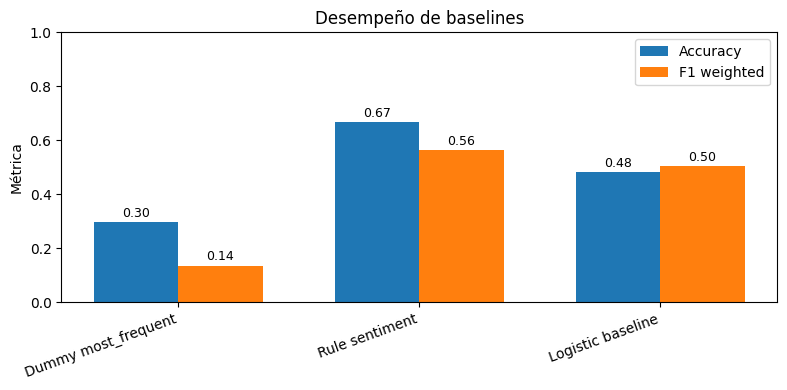

In [73]:
plt.figure(figsize=(8, 4))

x = np.arange(len(baseline_df))
bar_width = 0.35

plt.bar(x - bar_width/2, baseline_df["accuracy"], width=bar_width, label="Accuracy")
plt.bar(x + bar_width/2, baseline_df["f1_weighted"], width=bar_width, label="F1 weighted")

plt.xticks(x, baseline_df["model"], rotation=20, ha="right")
plt.ylim(0, 1)
plt.title("Desempeño de baselines")
plt.ylabel("Métrica")
plt.legend()

for i, row in baseline_df.iterrows():
    plt.text(i - bar_width/2, row["accuracy"] + 0.02, f"{row['accuracy']:.2f}", ha="center", fontsize=9)
    plt.text(i + bar_width/2, row["f1_weighted"] + 0.02, f"{row['f1_weighted']:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(FIGS_DIR / "week5_baseline_metrics.png", dpi=150)
plt.show()

# 10. Experimentos A/B

En esta sección se ejecutan variantes comparables contra el baseline.

Cada variante agrega un cambio específico en el conjunto de features.

| Experimento | Cambio principal |
|---|---|
| `Baseline_lag1` | usa solo `lag_sent_1` |
| `Var1_lag1_lag2` | agrega `lag_sent_2` |
| `Var2_lags_volume_shares` | agrega volumen de noticias y proporciones de sentimiento |
| `Var3_full_temporal` | agrega rolling y volatilidad temporal |

El objetivo es identificar si las nuevas features mejoran la métrica principal respecto al baseline.

In [74]:
experiments = [
    {
        "experiment": "Baseline_lag1",
        "features": ["lag_sent_1"],
        "note": "Baseline con sentimiento rezagado 1 día"
    },
    {
        "experiment": "Var1_lag1_lag2",
        "features": ["lag_sent_1", "lag_sent_2"],
        "note": "Agrega sentimiento rezagado 2 días"
    },
    {
        "experiment": "Var2_lags_volume_shares",
        "features": [
            "lag_sent_1",
            "lag_sent_2",
            "n_news_total",
            "share_pos",
            "share_neg",
            "share_neu"
        ],
        "note": "Agrega volumen y composición del sentimiento"
    },
    {
        "experiment": "Var3_full_temporal",
        "features": [
            "lag_sent_1",
            "lag_sent_2",
            "rolling_sent_3",
            "volatility_sent_3",
            "n_news_total",
            "share_pos",
            "share_neg",
            "share_neu"
        ],
        "note": "Agrega rolling y volatilidad temporal"
    }
]

ab_results = []
ab_predictions = {}
ab_scores = {}

for exp in experiments:
    name = exp["experiment"]
    feats = exp["features"]
    
    X_train = train_df[feats]
    X_test = test_df[feats]
    
    metrics, y_pred, y_score, fitted_model = evaluate_classifier(
        name,
        make_logreg(),
        X_train,
        y_train,
        X_test,
        y_test
    )
    
    metrics["features"] = ", ".join(feats)
    metrics["note"] = exp["note"]
    
    ab_results.append(metrics)
    ab_predictions[name] = y_pred
    ab_scores[name] = y_score

ab_df = pd.DataFrame(ab_results)

cols_order = [
    "model",
    "features",
    "accuracy",
    "f1_weighted",
    "f1_binary",
    "precision",
    "recall",
    "pr_auc",
    "elapsed_seconds",
    "n_features",
    "n_train",
    "n_test",
    "note"
]

ab_df = ab_df[cols_order]
display(ab_df)

ab_df.to_csv(LOGS_DIR / "metrics_experimentos_week5.csv", index=False)

,model,features,accuracy,f1_weighted,f1_binary,precision,recall,pr_auc,elapsed_seconds,n_features,n_train,n_test,note
0,Baseline_lag1,lag_sent_1,0.481481,0.503577,0.562500,0.692308,0.473684,0.777143,0.004998,1,61,27,Baseline con sentimiento rezagado 1 día
1,Var1_lag1_lag2,"lag_sent_1, lag_sent_2",0.481481,0.498765,0.533333,0.727273,0.421053,0.785882,0.004006,2,61,27,Agrega sentimiento rezagado 2 días
2,Var2_lags_volume_shares,"lag_sent_1, lag_sent_2, n_news_total, share_po...",0.407407,0.432660,0.500000,0.615385,0.421053,0.745685,0.005000,6,61,27,Agrega volumen y composición del sentimiento
3,Var3_full_temporal,"lag_sent_1, lag_sent_2, rolling_sent_3, volati...",0.444444,0.468494,0.545455,0.642857,0.473684,0.741278,0.005162,8,61,27,Agrega rolling y volatilidad temporal


## 11. Resultados comparables y gráfico único

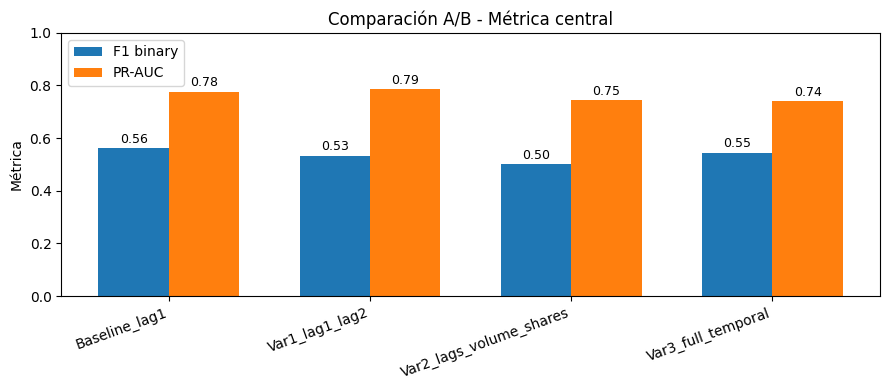

In [75]:
plt.figure(figsize=(9, 4))

x = np.arange(len(ab_df))
bar_width = 0.35

plt.bar(x - bar_width/2, ab_df["f1_binary"], width=bar_width, label="F1 binary")
plt.bar(x + bar_width/2, ab_df["pr_auc"], width=bar_width, label="PR-AUC")

plt.xticks(x, ab_df["model"], rotation=20, ha="right")
plt.ylim(0, 1)
plt.title("Comparación A/B - Métrica central")
plt.ylabel("Métrica")
plt.legend()

for i, row in ab_df.iterrows():
    plt.text(i - bar_width/2, row["f1_binary"] + 0.02, f"{row['f1_binary']:.2f}", ha="center", fontsize=9)
    plt.text(i + bar_width/2, row["pr_auc"] + 0.02, f"{row['pr_auc']:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(FIGS_DIR / "week5_ab_experiments.png", dpi=150)
plt.show()

# 12. PR Curve y validación reforzada con TimeSeriesSplit

En esta etapa se refuerza la validación experimental.

Primero se genera la curva Precision-Recall para comparar el desempeño de las variantes A/B.

Luego se aplica `TimeSeriesSplit`, que permite evaluar el modelo en varios cortes temporales respetando el orden de las fechas.

Esto permite reportar métricas promedio por fold y reducir el riesgo de obtener conclusiones por un único split.

En algunos folds puede ocurrir que el conjunto de entrenamiento tenga una sola clase. En ese caso, el fold se omite para evitar una validación inválida.

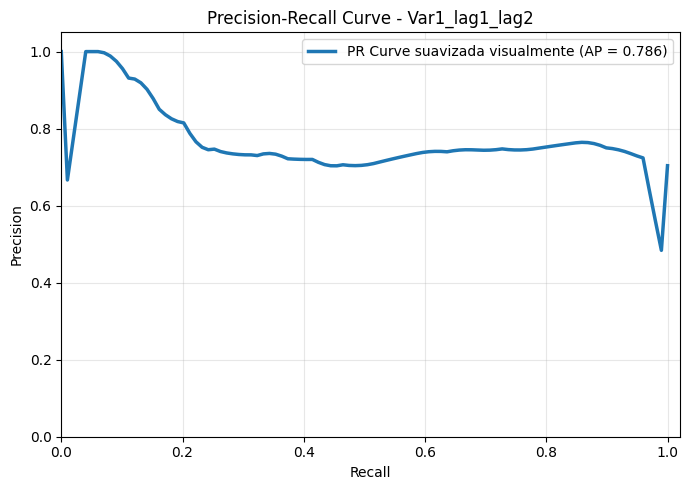

Mejor modelo: Var1_lag1_lag2
Average Precision / PR-AUC real: 0.7859


In [86]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import numpy as np
import matplotlib.pyplot as plt

best_model_name = (
    ab_df
    .sort_values(["pr_auc", "f1_binary"], ascending=False)
    .iloc[0]["model"]
)

y_score = ab_scores[best_model_name]

precision, recall, thresholds = precision_recall_curve(y_test, y_score)
ap = average_precision_score(y_test, y_score)

# Ordenar por recall
order = np.argsort(recall)
recall_sorted = recall[order]
precision_sorted = precision[order]

# Interpolación para visualización
recall_grid = np.linspace(0, 1, 100)
precision_interp = np.interp(recall_grid, recall_sorted, precision_sorted)

# Suavizado simple con promedio móvil
window = 9
kernel = np.ones(window) / window
precision_smooth = np.convolve(precision_interp, kernel, mode="same")

# Corrección de bordes
precision_smooth[0] = precision_sorted[0]
precision_smooth[-1] = precision_sorted[-1]
precision_smooth = np.clip(precision_smooth, 0, 1)

plt.figure(figsize=(7, 5))

plt.plot(
    recall_grid,
    precision_smooth,
    linewidth=2.5,
    label=f"PR Curve suavizada visualmente (AP = {ap:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve - {best_model_name}")
plt.ylim(0, 1.05)
plt.xlim(0, 1.02)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(FIGS_DIR / "week6_pr_curve_best_model_smooth.png", dpi=150)
plt.show()

print("Mejor modelo:", best_model_name)
print("Average Precision / PR-AUC real:", round(ap, 4))

In [88]:
# =========================
# Tabla final Semana 6
# =========================

week6_table = ab_df.copy()

week6_table = week6_table[[
    "model",
    "features",
    "accuracy",
    "f1_binary",
    "precision",
    "recall",
    "pr_auc",
    "elapsed_seconds",
    "note"
]].copy()

week6_table = week6_table.rename(columns={
    "model": "experimento",
    "features": "features",
    "accuracy": "accuracy",
    "f1_binary": "f1_principal",
    "precision": "precision",
    "recall": "recall",
    "pr_auc": "pr_auc_metrica_central",
    "elapsed_seconds": "latencia_segundos",
    "note": "cambio_realizado"
})

display(week6_table)

week6_table.to_csv(
    LOGS_DIR / "week6_resultados_comparables.csv",
    index=False,
    encoding="utf-8-sig"
)

,experimento,features,accuracy,f1_principal,precision,recall,pr_auc_metrica_central,latencia_segundos,cambio_realizado
0,Baseline_lag1,lag_sent_1,0.481481,0.562500,0.692308,0.473684,0.777143,0.004998,Baseline con sentimiento rezagado 1 día
1,Var1_lag1_lag2,"lag_sent_1, lag_sent_2",0.481481,0.533333,0.727273,0.421053,0.785882,0.004006,Agrega sentimiento rezagado 2 días
2,Var2_lags_volume_shares,"lag_sent_1, lag_sent_2, n_news_total, share_po...",0.407407,0.500000,0.615385,0.421053,0.745685,0.005000,Agrega volumen y composición del sentimiento
3,Var3_full_temporal,"lag_sent_1, lag_sent_2, rolling_sent_3, volati...",0.444444,0.545455,0.642857,0.473684,0.741278,0.005162,Agrega rolling y volatilidad temporal


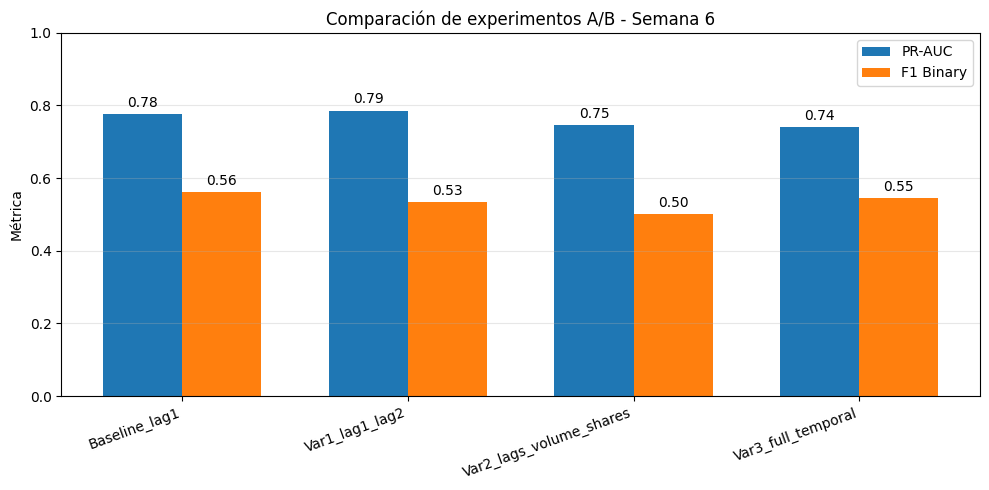

In [89]:
# =========================
# Gráfico único Semana 6: PR-AUC y F1
# =========================

plot_df = week6_table.copy()

x = np.arange(len(plot_df))
bar_width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - bar_width / 2,
    plot_df["pr_auc_metrica_central"],
    width=bar_width,
    label="PR-AUC"
)

plt.bar(
    x + bar_width / 2,
    plot_df["f1_principal"],
    width=bar_width,
    label="F1 Binary"
)

plt.xticks(x, plot_df["experimento"], rotation=20, ha="right")
plt.ylim(0, 1)
plt.ylabel("Métrica")
plt.title("Comparación de experimentos A/B - Semana 6")
plt.legend()
plt.grid(axis="y", alpha=0.3)

for i, row in plot_df.iterrows():
    plt.text(i - bar_width/2, row["pr_auc_metrica_central"] + 0.02, f"{row['pr_auc_metrica_central']:.2f}", ha="center")
    plt.text(i + bar_width/2, row["f1_principal"] + 0.02, f"{row['f1_principal']:.2f}", ha="center")

plt.tight_layout()
plt.savefig(FIGS_DIR / "week6_ab_metricas_centrales.png", dpi=150)
plt.show()

In [ ]:


base = week6_table[week6_table["experimento"] == "Baseline_lag1"].iloc[0]

decision_rows = []

for _, row in week6_table.iterrows():
    delta_pr_auc = row["pr_auc_metrica_central"] - base["pr_auc_metrica_central"]
    delta_f1 = row["f1_principal"] - base["f1_principal"]

    if row["experimento"] == "Baseline_lag1":
        decision = "Referencia"
        justificacion = "Modelo base para comparar las variantes."
    elif delta_pr_auc > 0 and delta_f1 >= 0:
        decision = "Adoptar"
        justificacion = "Mejora PR-AUC y mantiene/mejora F1 frente al baseline."
    elif delta_pr_auc > 0:
        decision = "Evaluar"
        justificacion = "Mejora PR-AUC, pero revisar F1 y estabilidad."
    else:
        decision = "Descartar"
        justificacion = "No mejora la métrica central frente al baseline."

    decision_rows.append({
        "experimento": row["experimento"],
        "delta_pr_auc_vs_baseline": delta_pr_auc,
        "delta_f1_vs_baseline": delta_f1,
        "latencia_segundos": row["latencia_segundos"],
        "decision": decision,
        "justificacion": justificacion
    })

week6_decision = pd.DataFrame(decision_rows)

display(week6_decision)

week6_decision.to_csv(
    LOGS_DIR / "week6_decision_experimental.csv",
    index=False,
    encoding="utf-8-sig"
)

,experimento,delta_pr_auc_vs_baseline,delta_f1_vs_baseline,latencia_segundos,decision,justificacion
0,Baseline_lag1,0.000000,0.000000,0.004998,Referencia,Modelo base para comparar las variantes.
1,Var1_lag1_lag2,0.008739,-0.029167,0.004006,Evaluar,"Mejora PR-AUC, pero revisar F1 y estabilidad."
2,Var2_lags_volume_shares,-0.031458,-0.062500,0.005000,Descartar,No mejora la métrica central frente al baseline.
3,Var3_full_temporal,-0.035864,-0.017045,0.005162,Descartar,No mejora la métrica central frente al baseline.


# 13. Decisión experimental preliminar

En esta sección se compara el desempeño de las variantes A/B.

La decisión se basa principalmente en:

- F1 Binary
- PR-AUC
- Accuracy
- costo/latencia aproximado

La variante seleccionada debe mejorar la métrica principal sin incrementar excesivamente el costo computacional.

In [77]:
decision_df = ab_df.copy()

best_row = decision_df.sort_values(["f1_binary", "pr_auc"], ascending=False).iloc[0]

def decide(row):
    if row["model"] == best_row["model"]:
        return "Adoptar"
    elif row["f1_binary"] < best_row["f1_binary"]:
        return "Descartar"
    else:
        return "Mantener como alternativa"

decision_df["decision"] = decision_df.apply(decide, axis=1)

decision_cols = [
    "model",
    "features",
    "accuracy",
    "f1_binary",
    "pr_auc",
    "elapsed_seconds",
    "decision",
    "note"
]

display(decision_df[decision_cols])

decision_df[decision_cols].to_csv(LOGS_DIR / "decision_experimental_week5.csv", index=False)

print("Modelo recomendado:", best_row["model"])
print("Justificación:")
print("- Mayor desempeño en F1 binary / PR-AUC dentro de los experimentos A/B.")
print("- Mantiene validación temporal.")
print("- No usa información futura, por lo tanto evita leakage.")

,model,features,accuracy,f1_binary,pr_auc,elapsed_seconds,decision,note
0,Baseline_lag1,lag_sent_1,0.481481,0.562500,0.777143,0.004998,Adoptar,Baseline con sentimiento rezagado 1 día
1,Var1_lag1_lag2,"lag_sent_1, lag_sent_2",0.481481,0.533333,0.785882,0.004006,Descartar,Agrega sentimiento rezagado 2 días
2,Var2_lags_volume_shares,"lag_sent_1, lag_sent_2, n_news_total, share_po...",0.407407,0.500000,0.745685,0.005000,Descartar,Agrega volumen y composición del sentimiento
3,Var3_full_temporal,"lag_sent_1, lag_sent_2, rolling_sent_3, volati...",0.444444,0.545455,0.741278,0.005162,Descartar,Agrega rolling y volatilidad temporal


Modelo recomendado: Baseline_lag1
Justificación:
- Mayor desempeño en F1 binary / PR-AUC dentro de los experimentos A/B.
- Mantiene validación temporal.
- No usa información futura, por lo tanto evita leakage.


# 14. Calibración ligera de umbral

En esta etapa se realiza una calibración ligera del threshold de decisión del mejor modelo experimental.

Por defecto, muchos clasificadores utilizan un umbral de `0.50` para decidir entre las clases positivas y negativas. Sin embargo, en datasets desbalanceados este valor no siempre es el más adecuado.

Por ello, se prueban distintos thresholds entre `0.30` y `0.70` para analizar cómo cambian las métricas principales.

Se evalúan:

| Métrica | Significado |
|---|---|
| Accuracy | porcentaje total de aciertos |
| F1 Binary | balance entre precision y recall de la clase positiva |
| Precision | proporción de predicciones positivas correctas |
| Recall | capacidad de detectar casos positivos |

El objetivo es identificar un threshold que mejore el desempeño del modelo respecto al valor estándar de 0.50.

Esta calibración no modifica el entrenamiento del modelo; únicamente cambia la regla de decisión final sobre las probabilidades predichas.

Modelo seleccionado para calibración: Baseline_lag1


,model,threshold,accuracy,f1_binary,f1_weighted,precision_binary,recall_binary
0,Baseline_lag1,0.30,0.740741,0.837209,0.696891,0.750000,0.947368
1,Baseline_lag1,0.35,0.740741,0.837209,0.696891,0.750000,0.947368
2,Baseline_lag1,0.40,0.703704,0.809524,0.668430,0.739130,0.894737
3,Baseline_lag1,0.45,0.592593,0.702703,0.599070,0.722222,0.684211
4,Baseline_lag1,0.50,0.481481,0.562500,0.503577,0.692308,0.473684
5,Baseline_lag1,0.55,0.407407,0.333333,0.372840,0.800000,0.210526
6,Baseline_lag1,0.60,0.333333,0.100000,0.209804,1.000000,0.052632
7,Baseline_lag1,0.65,0.333333,0.100000,0.209804,1.000000,0.052632
8,Baseline_lag1,0.70,0.333333,0.100000,0.209804,1.000000,0.052632


Umbral sugerido:


model               Baseline_lag1
threshold                     0.3
accuracy                 0.740741
f1_binary                0.837209
f1_weighted              0.696891
precision_binary             0.75
recall_binary            0.947368
Name: 0, dtype: object

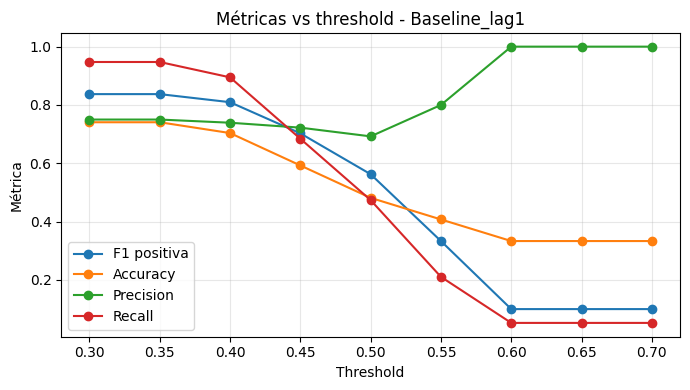

In [78]:
THRESHOLDS = np.arange(0.30, 0.71, 0.05)

threshold_rows = []

# Elegir mejor modelo según F1 binary y PR-AUC
best_model_name = (
    ab_df
    .sort_values(["f1_binary", "pr_auc"], ascending=False)
    .iloc[0]["model"]
)

print("Modelo seleccionado para calibración:", best_model_name)

if best_model_name in ab_scores:
    y_score = ab_scores[best_model_name]

    for th in THRESHOLDS:
        y_pred_th = (y_score >= th).astype(int)

        threshold_rows.append({
            "model": best_model_name,
            "threshold": round(float(th), 2),
            "accuracy": accuracy_score(y_test, y_pred_th),
            "f1_binary": f1_score(y_test, y_pred_th, zero_division=0),
            "f1_weighted": f1_score(y_test, y_pred_th, average="weighted", zero_division=0),
            "precision_binary": precision_score(y_test, y_pred_th, zero_division=0),
            "recall_binary": recall_score(y_test, y_pred_th, zero_division=0),
        })

threshold_df = pd.DataFrame(threshold_rows)

if not threshold_df.empty:
    display(threshold_df)

    best_threshold = (
        threshold_df
        .sort_values(["f1_binary", "accuracy"], ascending=False)
        .iloc[0]
    )

    print("Umbral sugerido:")
    display(best_threshold)

    plt.figure(figsize=(7, 4))
    plt.plot(threshold_df["threshold"], threshold_df["f1_binary"], marker="o", label="F1 positiva")
    plt.plot(threshold_df["threshold"], threshold_df["accuracy"], marker="o", label="Accuracy")
    plt.plot(threshold_df["threshold"], threshold_df["precision_binary"], marker="o", label="Precision")
    plt.plot(threshold_df["threshold"], threshold_df["recall_binary"], marker="o", label="Recall")

    plt.xlabel("Threshold")
    plt.ylabel("Métrica")
    plt.title(f"Métricas vs threshold - {best_model_name}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(FIGS_DIR / "week5_threshold_tuning.png", dpi=150)
    plt.show()

    threshold_df.to_csv(
        LOGS_DIR / "threshold_tuning_week5.csv",
        index=False,
        encoding="utf-8-sig"
    )
else:
    print("⚠ No se pudo realizar calibración de umbral.")

# 15. Decisión experimental

En esta sección se toma una decisión formal sobre cada variante.

Las opciones son:

| Decisión | Significado |
|---|---|
| Referencia | baseline usado como comparación |
| Adoptar | mejora la métrica principal con costo aceptable |
| Evaluar costo | mejora, pero requiere revisar latencia |
| Descartar | no mejora frente al baseline |

Esta etapa responde directamente al requerimiento del entregable: decidir si una variante se adopta o se descarta.

In [79]:
decision_rows = []

base_row = ab_df[ab_df["model"] == "Baseline_lag1"].iloc[0]

for _, row in ab_df.iterrows():
    delta_f1 = row["f1_binary"] - base_row["f1_binary"]
    delta_acc = row["accuracy"] - base_row["accuracy"]
    delta_pr_auc = row["pr_auc"] - base_row["pr_auc"]

    if row["model"] == "Baseline_lag1":
        decision = "Referencia"
        reason = "Baseline de comparación."
    elif delta_f1 > 0 and row["elapsed_seconds"] <= base_row["elapsed_seconds"] * 3:
        decision = "Adoptar"
        reason = "Mejora F1 con costo/latencia aceptable."
    elif delta_f1 > 0:
        decision = "Evaluar costo"
        reason = "Mejora F1, pero revisar latencia/costo."
    else:
        decision = "Descartar"
        reason = "No mejora la métrica principal frente al baseline."

    decision_rows.append({
        "experiment": row["model"],
        "features": row["features"],
        "accuracy": row["accuracy"],
        "f1_binary": row["f1_binary"],
        "pr_auc": row["pr_auc"],
        "elapsed_seconds": row["elapsed_seconds"],
        "delta_accuracy_vs_baseline": delta_acc,
        "delta_f1_vs_baseline": delta_f1,
        "delta_pr_auc_vs_baseline": delta_pr_auc,
        "decision": decision,
        "reason": reason,
    })

decision_df = pd.DataFrame(decision_rows)

display(decision_df)

decision_df.to_csv(
    LOGS_DIR / "experiment_decision_week5.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✓ Decisiones guardadas en logs/experiment_decision_week5.csv")

,experiment,features,accuracy,f1_binary,pr_auc,elapsed_seconds,delta_accuracy_vs_baseline,delta_f1_vs_baseline,delta_pr_auc_vs_baseline,decision,reason
0,Baseline_lag1,lag_sent_1,0.481481,0.562500,0.777143,0.004998,0.000000,0.000000,0.000000,Referencia,Baseline de comparación.
1,Var1_lag1_lag2,"lag_sent_1, lag_sent_2",0.481481,0.533333,0.785882,0.004006,0.000000,-0.029167,0.008739,Descartar,No mejora la métrica principal frente al basel...
2,Var2_lags_volume_shares,"lag_sent_1, lag_sent_2, n_news_total, share_po...",0.407407,0.500000,0.745685,0.005000,-0.074074,-0.062500,-0.031458,Descartar,No mejora la métrica principal frente al basel...
3,Var3_full_temporal,"lag_sent_1, lag_sent_2, rolling_sent_3, volati...",0.444444,0.545455,0.741278,0.005162,-0.037037,-0.017045,-0.035864,Descartar,No mejora la métrica principal frente al basel...


✓ Decisiones guardadas en logs/experiment_decision_week5.csv


# 16. Logs, figuras y reproducibilidad

En esta sección se guardan los resultados finales del experimento.

Se generan:

- métricas baseline
- métricas A/B
- resultados de TimeSeriesSplit
- calibración de umbral
- decisión experimental
- figuras del análisis
- resumen textual de ejecución

Los archivos se almacenan en:

```text
logs/
figs/

In [80]:
summary_txt = LOGS_DIR / "week5_experiment_summary.txt"

with open(summary_txt, "w", encoding="utf-8") as f:
    f.write("Métricas y experimentos Semana 5\n")
    f.write("=" * 60 + "\n\n")

    f.write(f"Fecha ejecución: {datetime.now().isoformat()}\n")
    f.write(f"START_DATE: {START_DATE}\n")
    f.write(f"END_DATE: {END_DATE}\n")
    f.write(f"RANDOM_SEED: {RANDOM_SEED}\n")
    f.write(f"PROJECT_ROOT: {PROJECT_ROOT}\n\n")

    f.write("Split temporal holdout:\n")
    f.write(f"Train: {train_df['date'].min()} → {train_df['date'].max()} | filas={len(train_df)}\n")
    f.write(f"Test : {test_df['date'].min()} → {test_df['date'].max()} | filas={len(test_df)}\n\n")

    f.write("Distribución target train:\n")
    f.write(y_train.value_counts().to_string())
    f.write("\n\n")

    f.write("Distribución target test:\n")
    f.write(y_test.value_counts().to_string())
    f.write("\n\n")

    f.write("Baselines iniciales:\n")
    f.write(baseline_df.to_string(index=False))
    f.write("\n\n")

    f.write("Experimentos A/B:\n")
    f.write(ab_df.to_string(index=False))
    f.write("\n\n")

    if "cv_summary" in globals() and len(cv_summary) > 0:
        f.write("Validación TimeSeriesSplit:\n")
        f.write(cv_summary.to_string(index=False))
        f.write("\n\n")

    if "threshold_df" in globals() and len(threshold_df) > 0:
        f.write("Calibración de umbral:\n")
        f.write(threshold_df.to_string(index=False))
        f.write("\n\n")

    if "decision_df" in globals() and len(decision_df) > 0:
        f.write("Decisión experimental:\n")
        f.write(decision_df.to_string(index=False))
        f.write("\n\n")

print("✓ Resumen guardado:", summary_txt)

print("\nFiguras generadas:")
for fp in sorted(FIGS_DIR.glob("week5_*.png")):
    print("-", fp.relative_to(PROJECT_ROOT))

print("\nLogs generados:")
for fp in sorted(LOGS_DIR.glob("*week5*")):
    print("-", fp.relative_to(PROJECT_ROOT))

✓ Resumen guardado: C:\Users\Thomy\Cursos\Proyecto_1\Proyecto_Tesis_1\news-sentiment-pipeline\logs\week5_experiment_summary.txt

Figuras generadas:
- figs\week5_ab_experiments.png
- figs\week5_ab_metrics_comparison.png
- figs\week5_baseline_metrics.png
- figs\week5_daily_sentiment_shares.png
- figs\week5_dist_sent_index_mean.png
- figs\week5_news_per_day.png
- figs\week5_pr_curve.png
- figs\week5_pr_curve_best_model.png
- figs\week5_threshold_tuning.png
- figs\week5_timeseries_cv_summary.png

Logs generados:
- logs\data_version_week5.json
- logs\decision_experimental_week5.csv
- logs\experiment_decision_week5.csv
- logs\experiments_week5.csv
- logs\metrics_baseline_week5.csv
- logs\metrics_experimentos_week5.csv
- logs\threshold_tuning_week5.csv
- logs\time_series_cv_folds_week5.csv
- logs\time_series_cv_summary_week5.csv
- logs\timeseries_cv_folds_week5.csv
- logs\timeseries_cv_summary_week5.csv
- logs\week5_experiment_summary.txt
